<b><font size="6"> Data Mining Project - Bonus Components - Group 40 2025/2026 </font></b><br><br>
<i> <font size="4"> Amazing International Airlines Inc. (AIAI)</font></i>

`Group 40`

20250380 Maria Fonseca <br>
20250405 Ana Macedo <br>
20250453 Lourenço Silva <br>

<a class="anchor" id="1">

# **1. Import libraries**

[Back to TOP](#TOP)
</a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#!pip install scikit-fuzzy
import skfuzzy as fuzz

<a class="anchor" id="2">

# **2. Load Datasets**

[Back to TOP](#TOP)
</a>

In [28]:
# Dataset with clustering features and labels of merged clusters and pca components
df_clustering = pd.read_csv("../cluster_data/final_clusters.csv").set_index("Loyalty#")

# Dataset with categorical features only
df_categorical = pd.read_csv("../cluster_data/categorical_features.csv").set_index("Loyalty#")

# Datasets used for clustering with perspective features
df_VE = pd.read_csv("../cluster_data/df_VE.csv").set_index("Loyalty#")
df_PP = pd.read_csv("../cluster_data/df_PP.csv").set_index("Loyalty#")

# Dataset before feature selection
clv_no_scaling = pd.read_csv("../cluster_data/clv_no_scaling.csv").set_index("Loyalty#")

<a class="anchor" id="3">

# **3. Extra 1 - Financial Impact Modeling**

[Back to TOP](#TOP)
</a>

In [29]:
# Create a bonus dataset merging clustering and categorical features
df_bonus = df_clustering.merge(
    df_categorical,
    on="Loyalty#",
    how="left"
)

# Add Customer Lifetime Value to the bonus dataset
df_bonus['CLV'] = clv_no_scaling['Customer Lifetime Value']

In [30]:
# Assign CLV bins based on quantiles to analyze distribution across clusters
clv_distribution = pd.crosstab(
        df_bonus["merged_labels"],
        df_bonus["CLV_Bins"],
        normalize="index"
    )

clv_distribution

CLV_Bins,High,Low,Medium
merged_labels,,,
0,0.353860,0.301517,0.344623
1,0.325965,0.348607,0.325429
2,0.286254,0.380665,0.333082
3,0.321081,0.335135,0.343784
4,0.339529,0.332094,0.328377
5,0.340013,0.319973,0.340013


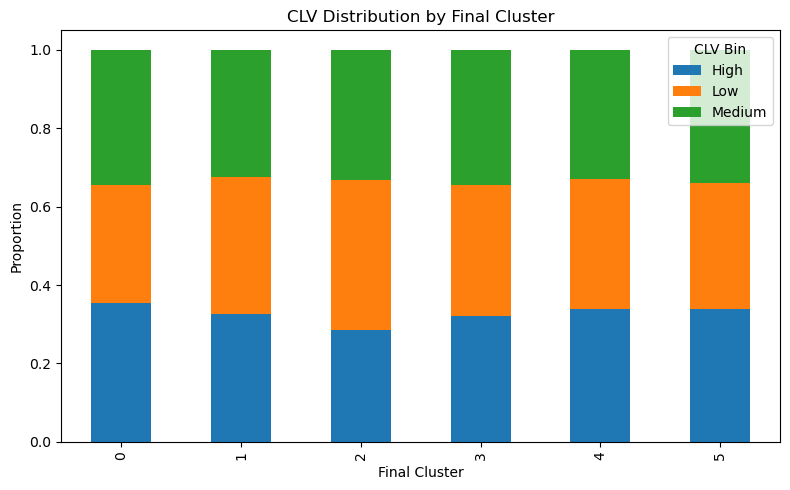

In [31]:
# Plot the CLV distribution across final clusters
clv_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("CLV Distribution by Final Cluster")
plt.ylabel("Proportion")
plt.xlabel("Final Cluster")
plt.legend(title="CLV Bin")
plt.tight_layout()
plt.show()


In [32]:
# Calculate average CLV and average CLV score per cluster
clv_map = {"Low": 1, "Medium": 2, "High": 3}
df_bonus["CLV_score"] = df_bonus["CLV_Bins"].map(clv_map)

cluster_value = (
    df_bonus
    .groupby("merged_labels")
    .agg(
        avg_clv=("CLV", "mean"),        
        avg_clv_score=("CLV_score", "mean"),  
        size=("CLV", "count")
    )
    .sort_values("avg_clv_score", ascending=False)
)
cluster_value

,avg_clv,avg_clv_score,size
merged_labels,,,
0,7997.731698,2.052342,4547
5,8211.027108,2.020040,1497
4,7946.305849,2.007435,807
3,7630.474616,1.985946,925
1,7876.578842,1.977358,7464
2,7264.094169,1.905589,1324


In [33]:
# Define quantile thresholds for priority assignment
q1 = cluster_value["avg_clv_score"].quantile(0.33)
q2 = cluster_value["avg_clv_score"].quantile(0.66)

def assign_priority(x):
    if x >= q2:
        return "High priority"
    elif x >= q1:
        return "Medium priority"
    else:
        return "Low priority"

cluster_value["priority"] = cluster_value["avg_clv_score"].apply(assign_priority)
cluster_value

,avg_clv,avg_clv_score,size,priority
merged_labels,,,,
0,7997.731698,2.052342,4547,High priority
5,8211.027108,2.020040,1497,High priority
4,7946.305849,2.007435,807,Medium priority
3,7630.474616,1.985946,925,Medium priority
1,7876.578842,1.977358,7464,Low priority
2,7264.094169,1.905589,1324,Low priority


In [48]:
# Define assumptions for each priority level
assumptions = {
    "High priority":   {"cost": 25, "lift": 0.015},
    "Medium priority": {"cost": 15, "lift": 0.010},
    "Low priority":    {"cost": 3, "lift": 0.003},
}

In [49]:
# Calculate ROI for each cluster based on assumptions
roi_table = cluster_value.copy()

# Map cost per customer and expected lift from assumptions
roi_table["cost_per_customer"] = roi_table["priority"].map(
    lambda x: assumptions[x]["cost"]
)

# Map expected lift from assumptions
roi_table["expected_lift"] = roi_table["priority"].map(
    lambda x: assumptions[x]["lift"]
)

# Define target rates for each priority level
target_rate = {
    "High priority": 0.6,
    "Medium priority": 0.4,
    "Low priority": 0.2
}

# Calculate number of customers targeted based on priority
roi_table["customers_targeted"] = (
    roi_table["size"] *
    roi_table["priority"].map(target_rate)
)

# Calculate expected benefit, expected cost, and ROI
roi_table["expected_benefit"] = (
    roi_table["avg_clv"] *
    roi_table["expected_lift"] *
    roi_table["customers_targeted"]
)

# Calculate expected cost
roi_table["expected_cost"] = (
    roi_table["cost_per_customer"] *
    roi_table["customers_targeted"]
)

# Calculate ROI
roi_table["ROI"] = (
    (roi_table["expected_benefit"] - roi_table["expected_cost"]) /
    roi_table["expected_cost"]
)

# Sort ROI table by ROI descending
roi_table.sort_values("ROI", ascending=False)

# Prepare timeline table with relevant columns
timeline = roi_table[[
    "priority",
    "avg_clv",
    "avg_clv_score",
    "size",
    "ROI"
]].copy()

timeline

,priority,avg_clv,avg_clv_score,size,ROI
merged_labels,,,,,
0,High priority,7997.731698,2.052342,4547,3.798639
5,High priority,8211.027108,2.020040,1497,3.926616
4,Medium priority,7946.305849,2.007435,807,4.297537
3,Medium priority,7630.474616,1.985946,925,4.086983
1,Low priority,7876.578842,1.977358,7464,6.876579
2,Low priority,7264.094169,1.905589,1324,6.264094


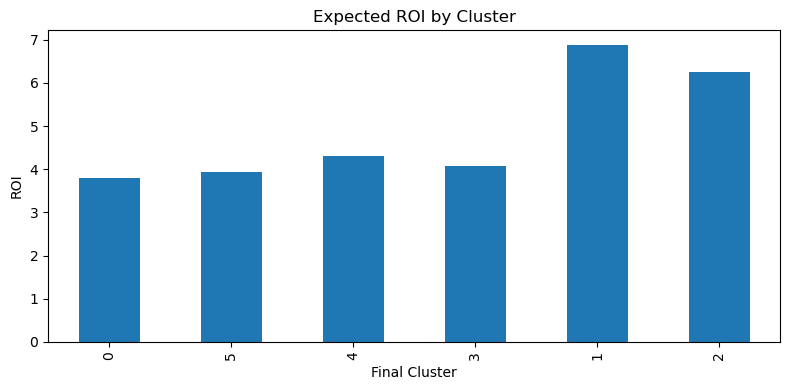

In [50]:
# Plot the ROI for each cluster
roi_table["ROI"].plot(kind="bar", figsize=(8, 4))
plt.title("Expected ROI by Cluster")
plt.ylabel("ROI")
plt.xlabel("Final Cluster")
plt.tight_layout()
plt.show()


<a class="anchor" id="4">

# **4. Extra 2 - Fuzzy Clustering Implementation**

[Back to TOP](#TOP)
</a>

In [51]:
# Fuzzy C-Means parameters
# c_VE and c_PP match the k used in k-means clustering
c_VE = 6   # number of clusters for VE perspective
c_PP = 5   # number of clusters for PP perspective


# 1. Fuzzy C-Means — VE Perspective

# Run Fuzzy C-Means on VE data
cntr_VE, U_VE, _, _, jm_VE, _, fpc_VE = fuzz.cluster.cmeans(
    df_VE.T,              # transpose required by skfuzzy
    c=c_VE,              # number of clusters
    m=2.0,               # fuzziness parameter
    error=1e-5,          # stopping criterion
    maxiter=1000,
    init=None,
    seed=42
)

# Transpose membership matrix to (n_samples, n_clusters)
U_VE = U_VE.T

# Hard cluster labels derived from fuzzy memberships
labels_fcm_VE = np.argmax(U_VE, axis=1)

# Maximum membership degree for each customer
u_max_VE = U_VE.max(axis=1)

# Sort membership degrees for each customer
u_sorted_VE = np.sort(U_VE, axis=1)

# Margin between the two highest memberships (overlap indicator)
margin_VE = u_sorted_VE[:, -1] - u_sorted_VE[:, -2]



# 2. Fuzzy C-Means — PP Perspective

# Run Fuzzy C-Means on PP data
cntr_PP, U_PP, _, _, jm_PP, _, fpc_PP = fuzz.cluster.cmeans(
    df_PP.T,              # transpose required by skfuzzy
    c=c_PP,              # number of clusters
    m=2.0,               # fuzziness parameter
    error=1e-5,          # stopping criterion
    maxiter=1000,
    init=None,
    seed=42
)

# Transpose membership matrix to (n_samples, n_clusters)
U_PP = U_PP.T

# Hard cluster labels derived from fuzzy memberships
labels_fcm_PP = np.argmax(U_PP, axis=1)

# Maximum membership degree for each customer
u_max_PP = U_PP.max(axis=1)

# Sort membership degrees for each customer
u_sorted_PP = np.sort(U_PP, axis=1)

# Margin between the two highest memberships (overlap indicator)
margin_PP = u_sorted_PP[:, -1] - u_sorted_PP[:, -2]



# 3. Quick sanity checks and summary metrics

# Print Fuzzy Partition Coefficient and share of high-confidence customers
print(f"VE FPC: {fpc_VE:.4f} | High confidence share: {(u_max_VE >= 0.7).mean():.4f}")
print(f"PP FPC: {fpc_PP:.4f} | High confidence share: {(u_max_PP >= 0.7).mean():.4f}")

VE FPC: 0.4070 | High confidence share: 0.2021
PP FPC: 0.3363 | High confidence share: 0.0937


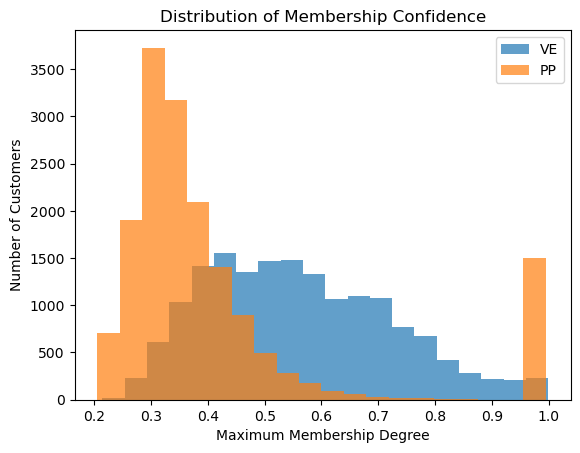

In [52]:
# Plot histograms of maximum membership degrees for VE and PP perspectives
plt.figure()
plt.hist(u_max_VE, bins=20, alpha=0.7, label='VE')
plt.hist(u_max_PP, bins=20, alpha=0.7, label='PP')
plt.xlabel('Maximum Membership Degree')
plt.ylabel('Number of Customers')
plt.legend()
plt.title('Distribution of Membership Confidence')
plt.show()

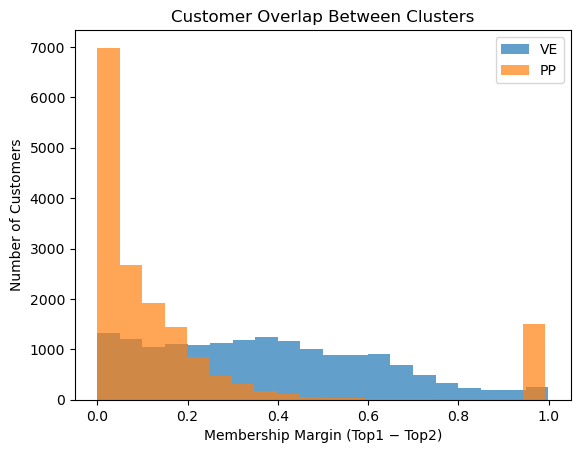

In [53]:
# Plot histograms of membership margins for VE and PP perspectives
plt.figure()
plt.hist(margin_VE, bins=20, alpha=0.7, label='VE')
plt.hist(margin_PP, bins=20, alpha=0.7, label='PP')
plt.xlabel('Membership Margin (Top1 − Top2)')
plt.ylabel('Number of Customers')
plt.legend()
plt.title('Customer Overlap Between Clusters')
plt.show()


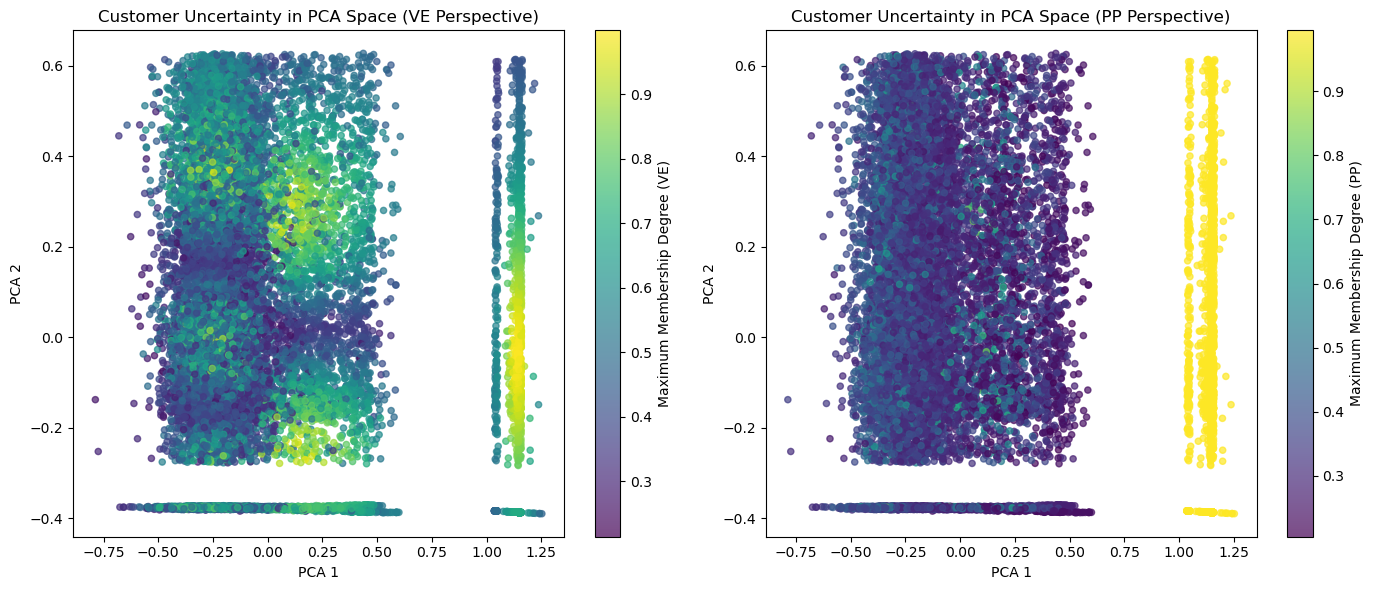

In [17]:
# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# VE Perspective
sc1 = axes[0].scatter(
    df_clustering['pca_1'],
    df_clustering['pca_2'],
    c=u_max_VE,
    s=20,
    alpha=0.7
)
plt.colorbar(sc1, ax=axes[0], label='Maximum Membership Degree (VE)')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].set_title('Customer Uncertainty in PCA Space (VE Perspective)')

# PP Perspective
sc2 = axes[1].scatter(
    df_clustering['pca_1'],
    df_clustering['pca_2'],
    c=u_max_PP,
    s=20,
    alpha=0.7
)
plt.colorbar(sc2, ax=axes[1], label='Maximum Membership Degree (PP)')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].set_title('Customer Uncertainty in PCA Space (PP Perspective)')

plt.tight_layout()
plt.show()
